# Model

In [1]:
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [2]:
DATA_DIR = Path("../../data")

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

TARGET_COL = "cnt"
LEAKAGE_COLS = ["casual", "registered"]
DROP_COLS = ["instant", "dteday"] + LEAKAGE_COLS

feature_cols = [
    c for c in train_df.columns
    if c not in DROP_COLS + [TARGET_COL]
]

print("Train/Val/Test:", train_df.shape, val_df.shape, test_df.shape)
print("Feature columns (leakage removed):", feature_cols)

train_df.head()

Train/Val/Test: (12165, 17) (1738, 17) (3476, 17)
Feature columns (leakage removed): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
def fit_standardizer(df, columns):
    mu = df[columns].mean()
    sigma = df[columns].std().replace(0, 1.0)
    return mu, sigma


def transform_standardize(df, columns, mu, sigma):
    return ((df[columns] - mu) / sigma).to_numpy(dtype=float)


def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])


def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))


def r2_score(y_true, y_pred):
    y_bar = np.mean(y_true)
    ss_tot = np.sum((y_true - y_bar) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-12))


def summarize_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "MSE": mse(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


mu_x, sigma_x = fit_standardizer(train_df, feature_cols)

X_train_std = transform_standardize(train_df, feature_cols, mu_x, sigma_x)
X_val_std = transform_standardize(val_df, feature_cols, mu_x, sigma_x)
X_test_std = transform_standardize(test_df, feature_cols, mu_x, sigma_x)

y_train = train_df[TARGET_COL].to_numpy(dtype=float)
y_val = val_df[TARGET_COL].to_numpy(dtype=float)
y_test = test_df[TARGET_COL].to_numpy(dtype=float)

X_train = add_intercept(X_train_std)
X_val = add_intercept(X_val_std)
X_test = add_intercept(X_test_std)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (12165, 13)
X_val shape: (1738, 13)
X_test shape: (3476, 13)


## 1) Linear Regression: Normal Equation, Mini-batch GD, Gauss-Markov checks, WLS

Training time (seconds):
             Model  Time_sec
0  Normal Equation  0.022555
1    Mini-batch GD  0.448206

Validation/Test metrics:
                model           MSE        RMSE        R2
0      NormalEq (val)  34912.402204  186.848608  0.271382
1   MiniBatchGD (val)  34917.575876  186.862452  0.271275
2     NormalEq (test)  33651.302610  183.442914  0.307779
3  MiniBatchGD (test)  33654.252644  183.450954  0.307719


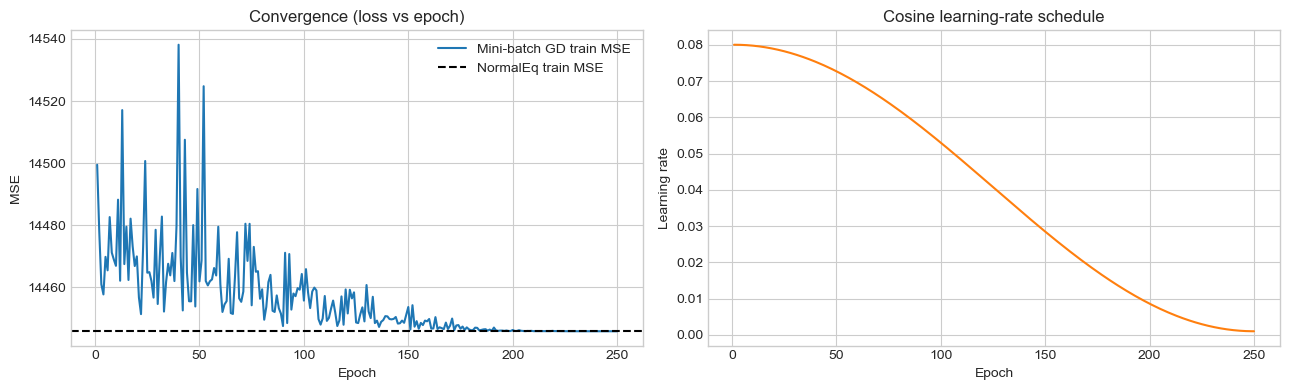

In [4]:
def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y


def mini_batch_gd(
    X,
    y,
    epochs=250,
    batch_size=256,
    lr0=0.08,
    schedule="cosine",
    step_size=40,
    gamma=0.5,
):
    n = X.shape[0]
    w = np.zeros(X.shape[1], dtype=float)
    history = {"epoch": [], "train_mse": [], "lr": []}

    indices = np.arange(n)
    t0 = time.perf_counter()

    for epoch in range(epochs):
        if schedule == "cosine":
            min_lr = 1e-3
            lr = min_lr + 0.5 * (lr0 - min_lr) * (1 + np.cos(np.pi * epoch / max(1, epochs - 1)))
        else:
            lr = lr0 * (gamma ** (epoch // step_size))

        np.random.shuffle(indices)

        for s in range(0, n, batch_size):
            batch_idx = indices[s:s + batch_size]
            Xb = X[batch_idx]
            yb = y[batch_idx]
            grad = (Xb.T @ (Xb @ w - yb)) / len(batch_idx)
            w -= lr * grad

        train_pred = X @ w
        history["epoch"].append(epoch + 1)
        history["train_mse"].append(mse(y, train_pred))
        history["lr"].append(lr)

    elapsed = time.perf_counter() - t0
    return w, history, elapsed


# Fit Normal Equation
t0 = time.perf_counter()
w_ne = normal_equation(X_train, y_train)
time_ne = time.perf_counter() - t0

# Fit Mini-batch GD with cosine annealing
w_gd, hist_gd, time_gd = mini_batch_gd(
    X_train,
    y_train,
    epochs=250,
    batch_size=256,
    lr0=0.08,
    schedule="cosine",
)

# Compare performance
metrics_linear = []
metrics_linear.append(summarize_metrics("NormalEq (val)", y_val, X_val @ w_ne))
metrics_linear.append(summarize_metrics("MiniBatchGD (val)", y_val, X_val @ w_gd))
metrics_linear.append(summarize_metrics("NormalEq (test)", y_test, X_test @ w_ne))
metrics_linear.append(summarize_metrics("MiniBatchGD (test)", y_test, X_test @ w_gd))

metrics_linear_df = pd.DataFrame(metrics_linear)

print("Training time (seconds):")
print(pd.DataFrame({"Model": ["Normal Equation", "Mini-batch GD"], "Time_sec": [time_ne, time_gd]}))
print("\nValidation/Test metrics:")
print(metrics_linear_df)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(hist_gd["epoch"], hist_gd["train_mse"], label="Mini-batch GD train MSE")
ax[0].axhline(mse(y_train, X_train @ w_ne), color="black", linestyle="--", label="NormalEq train MSE")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE")
ax[0].set_title("Convergence (loss vs epoch)")
ax[0].legend()

ax[1].plot(hist_gd["epoch"], hist_gd["lr"], color="tab:orange")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Learning rate")
ax[1].set_title("Cosine learning-rate schedule")

plt.tight_layout()
plt.show()

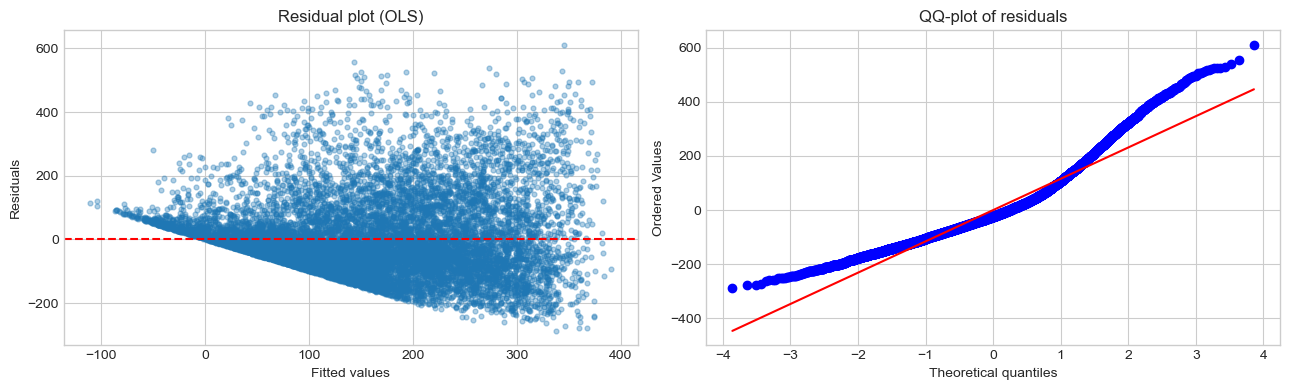

Breusch-Pagan test: LM=1093.4954, df=12, p-value=0.000000
=> Reject H0 at 5%: heteroscedasticity is likely present.


In [5]:
def breusch_pagan_test(X, residuals):
    """
    LM version of Breusch-Pagan test.
    Null hypothesis: homoscedasticity.
    """
    n = X.shape[0]
    e2 = residuals ** 2
    Z = X  # include intercept

    gamma = np.linalg.pinv(Z.T @ Z) @ Z.T @ e2
    e2_hat = Z @ gamma

    ss_tot = np.sum((e2 - e2.mean()) ** 2) + 1e-12
    ss_reg = np.sum((e2_hat - e2.mean()) ** 2)
    r2_aux = ss_reg / ss_tot

    lm_stat = n * r2_aux
    dof = Z.shape[1] - 1
    p_value = 1.0 - stats.chi2.cdf(lm_stat, dof)
    return lm_stat, p_value, dof


train_pred_ne = X_train @ w_ne
residuals_ne = y_train - train_pred_ne

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].scatter(train_pred_ne, residuals_ne, alpha=0.35, s=12)
ax[0].axhline(0.0, color="red", linestyle="--")
ax[0].set_title("Residual plot (OLS)")
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")

stats.probplot(residuals_ne, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot of residuals")

plt.tight_layout()
plt.show()

bp_lm, bp_p, bp_df = breusch_pagan_test(X_train, residuals_ne)
print(f"Breusch-Pagan test: LM={bp_lm:.4f}, df={bp_df}, p-value={bp_p:.6f}")
if bp_p < 0.05:
    print("=> Reject H0 at 5%: heteroscedasticity is likely present.")
else:
    print("=> Fail to reject H0 at 5%: no strong evidence of heteroscedasticity.")

In [6]:
def weighted_normal_equation(X, y, weights):
    # weights is a vector with length n.
    xtw = X.T * weights
    return np.linalg.pinv(xtw @ X) @ (xtw @ y)


# Build WLS if heteroscedasticity is detected.
if bp_p < 0.05:
    # Regress squared residuals on X to estimate conditional variance.
    gamma_var = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ (residuals_ne ** 2)
    sigma2_hat = X_train @ gamma_var
    floor = np.percentile(residuals_ne ** 2, 5)
    sigma2_hat = np.clip(sigma2_hat, floor, None)
    w_obs = 1.0 / (sigma2_hat + 1e-8)
    w_wls = weighted_normal_equation(X_train, y_train, w_obs)
    wls_note = "WLS fitted because BP p < 0.05"
else:
    w_wls = w_ne.copy()
    wls_note = "WLS skipped (BP did not detect strong heteroscedasticity)"

print(wls_note)

wls_results = pd.DataFrame([
    summarize_metrics("OLS (val)", y_val, X_val @ w_ne),
    summarize_metrics("WLS (val)", y_val, X_val @ w_wls),
    summarize_metrics("OLS (test)", y_test, X_test @ w_ne),
    summarize_metrics("WLS (test)", y_test, X_test @ w_wls),
])

wls_results

WLS fitted because BP p < 0.05


,model,MSE,RMSE,R2
0,OLS (val),34912.402204,186.848608,0.271382
1,WLS (val),38727.143280,196.792132,0.191769
2,OLS (test),33651.302610,183.442914,0.307779
3,WLS (test),38894.730312,197.217470,0.199920
